In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# 1) 财报数据
# =========================
window_width =10
revenue_data = [
    {
        "earnings_date": "2024-11-06",
        "quarter": "Q1 25",
        "actual_revenue_b": 1.883,
        "consensus_estimate_revenue_b": np.nan,
        "actual_EPS": 1.81,
        "consensus_estimate_EPS": np.nan,
        "Profit": 263,
    },
    {
        "earnings_date": "2025-01-29",
        "quarter": "Q2 25",
        "actual_revenue_b": 1.876,
        "consensus_estimate_revenue_b": 1.98,
        "actual_EPS": 1.23,
        "consensus_estimate_EPS": 1.16,
        "Profit": 178,
    },
    {
        "earnings_date": "2025-05-07",
        "quarter": "Q3 25",
        "actual_revenue_b": 1.695,
        "consensus_estimate_revenue_b": 1.52,
        "actual_EPS": -0.30,
        "consensus_estimate_EPS": -0.40,
        "Profit": -43,
    },
    {
        "earnings_date": "2025-08-14",
        "quarter": "Q4 25",
        "actual_revenue_b": 1.901,
        "consensus_estimate_revenue_b": 1.94,
        "actual_EPS": 0.29,
        "consensus_estimate_EPS": 0.05,
        "Profit": 42,
    },
    {
        "earnings_date": "2025-11-06",
        "quarter": "Q1 26",
        "actual_revenue_b": 2.308,
        "consensus_estimate_revenue_b": 2.26,
        "actual_EPS": 1.22,
        "consensus_estimate_EPS": 0.84,
        "Profit": 181,
    },
    {
        "earnings_date": "2026-01-29",
        "quarter": "Q2 26",
        "actual_revenue_b": 3.025,
        "consensus_estimate_revenue_b": 2.60,
        "actual_EPS": 6.20,
        "consensus_estimate_EPS": 3.38,
        "Profit": 967,
    },
    {
        "earnings_date": "2026-04-30",
        "quarter": "Q3 26",
        "actual_revenue_b": 5.95,
        "consensus_estimate_revenue_b": 4.16,
        "actual_EPS": 23.41,
        "consensus_estimate_EPS": 12.48,
        "Profit": 3675,
    },
    

]

df = pd.DataFrame(revenue_data)
df["earnings_date"] = pd.to_datetime(df["earnings_date"])
df = df.sort_values("earnings_date").reset_index(drop=True)

# =========================
# 2) 财务指标
# =========================
df["revenue_surprise_pct"] = (
    (df["actual_revenue_b"] - df["consensus_estimate_revenue_b"])
    / df["consensus_estimate_revenue_b"]
) * 100
df["eps_surprise_ratio"] = (
    (df["actual_EPS"] - df["consensus_estimate_EPS"])
    / df["consensus_estimate_EPS"].abs()
) * 100

prev_revenue_qoq = df["actual_revenue_b"].shift(1)
prev_eps_qoq = df["actual_EPS"].shift(1)
prev_profit_qoq = df["Profit"].shift(1)

prev_revenue_yoy = df["actual_revenue_b"].shift(4)
prev_eps_yoy = df["actual_EPS"].shift(4)
prev_profit_yoy = df["Profit"].shift(4)

df["revenue_qoq_growth_pct"] = ((df["actual_revenue_b"] - prev_revenue_qoq) / prev_revenue_qoq.abs()) * 100
df["eps_qoq_growth_pct"] = ((df["actual_EPS"] - prev_eps_qoq) / prev_eps_qoq.abs()) * 100
df["profit_qoq_growth_pct"] = ((df["Profit"] - prev_profit_qoq) / prev_profit_qoq.abs()) * 100

df["revenue_yoy_growth_pct"] = ((df["actual_revenue_b"] - prev_revenue_yoy) / prev_revenue_yoy.abs()) * 100
df["eps_yoy_growth_pct"] = ((df["actual_EPS"] - prev_eps_yoy) / prev_eps_yoy.abs()) * 100
df["profit_yoy_growth_pct"] = ((df["Profit"] - prev_profit_yoy) / prev_profit_yoy.abs()) * 100

# =========================
# 3) 拉取日线
# =========================
ticker = yf.Ticker("SNDK")
daily_df = ticker.history(period="max", interval="1d", auto_adjust=False)

daily_df = daily_df.reset_index()
daily_df["Date"] = pd.to_datetime(daily_df["Date"], errors="coerce")

# 去掉时区
if getattr(daily_df["Date"].dt, "tz", None) is not None:
    try:
        daily_df["Date"] = daily_df["Date"].dt.tz_localize(None)
    except Exception:
        pass

daily_df = daily_df.sort_values("Date").reset_index(drop=True)

# 首个交易日
first_trade_date = daily_df["Date"].min()

# =========================
# 4) 计算财报日前后15个交易日平均收盘价
#    规则：
#    - 财报日期早于首个交易日 -> NaN
#    - 否则取财报日前15 + 财报后15 的可用交易日
#    - 不足30天也照算
# =========================
avg_close_30 = []
num_obs_used = []

for ed in df["earnings_date"]:
    if ed < first_trade_date:
        avg_close_30.append(np.nan)
        num_obs_used.append(0)
        continue

    before_window = daily_df[daily_df["Date"] < ed].tail(window_width)
    after_window = daily_df[daily_df["Date"] > ed].head(window_width)

    window = pd.concat([before_window, after_window], ignore_index=True)

    if window.empty:
        avg_price = np.nan
        n_obs = 0
    else:
        avg_price = window["Close"].mean()
        n_obs = len(window)

    avg_close_30.append(avg_price)
    num_obs_used.append(n_obs)

df[f"avg_close_{window_width*2}tradingdays_around_earnings"] = avg_close_30
df["num_obs_used"] = num_obs_used

# =========================
# 5) 输出
# =========================
display(df)


# =========================


,earnings_date,quarter,actual_revenue_b,consensus_estimate_revenue_b,actual_EPS,consensus_estimate_EPS,Profit,revenue_surprise_pct,eps_surprise_ratio,revenue_qoq_growth_pct,eps_qoq_growth_pct,profit_qoq_growth_pct,revenue_yoy_growth_pct,eps_yoy_growth_pct,profit_yoy_growth_pct,avg_close_20tradingdays_around_earnings,num_obs_used
0,2024-11-06,Q1 25,1.883,NaN,1.81,NaN,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2025-01-29,Q2 25,1.876,1.98,1.23,1.16,178,-5.252525,6.034483,-0.371747,-32.044199,-32.319392,NaN,NaN,NaN,NaN,0
2,2025-05-07,Q3 25,1.695,1.52,-0.30,-0.40,-43,11.513158,25.000000,-9.648188,-124.390244,-124.157303,NaN,NaN,NaN,36.319500,20
3,2025-08-14,Q4 25,1.901,1.94,0.29,0.05,42,-2.010309,480.000000,12.153392,196.666667,197.674419,NaN,NaN,NaN,44.869000,20
4,2025-11-06,Q1 26,2.308,2.26,1.22,0.84,181,2.123894,45.238095,21.409784,320.689655,330.952381,22.570366,-32.596685,-31.178707,221.769502,20
5,2026-01-29,Q2 26,3.025,2.60,6.20,3.38,967,16.346154,83.431953,31.065858,408.196721,434.254144,61.247335,404.065041,443.258427,533.629001,20
6,2026-04-30,Q3 26,5.950,4.16,23.41,12.48,3675,43.028846,87.580128,96.694215,277.580645,280.041365,251.032448,7903.333333,8646.511628,1039.580764,13


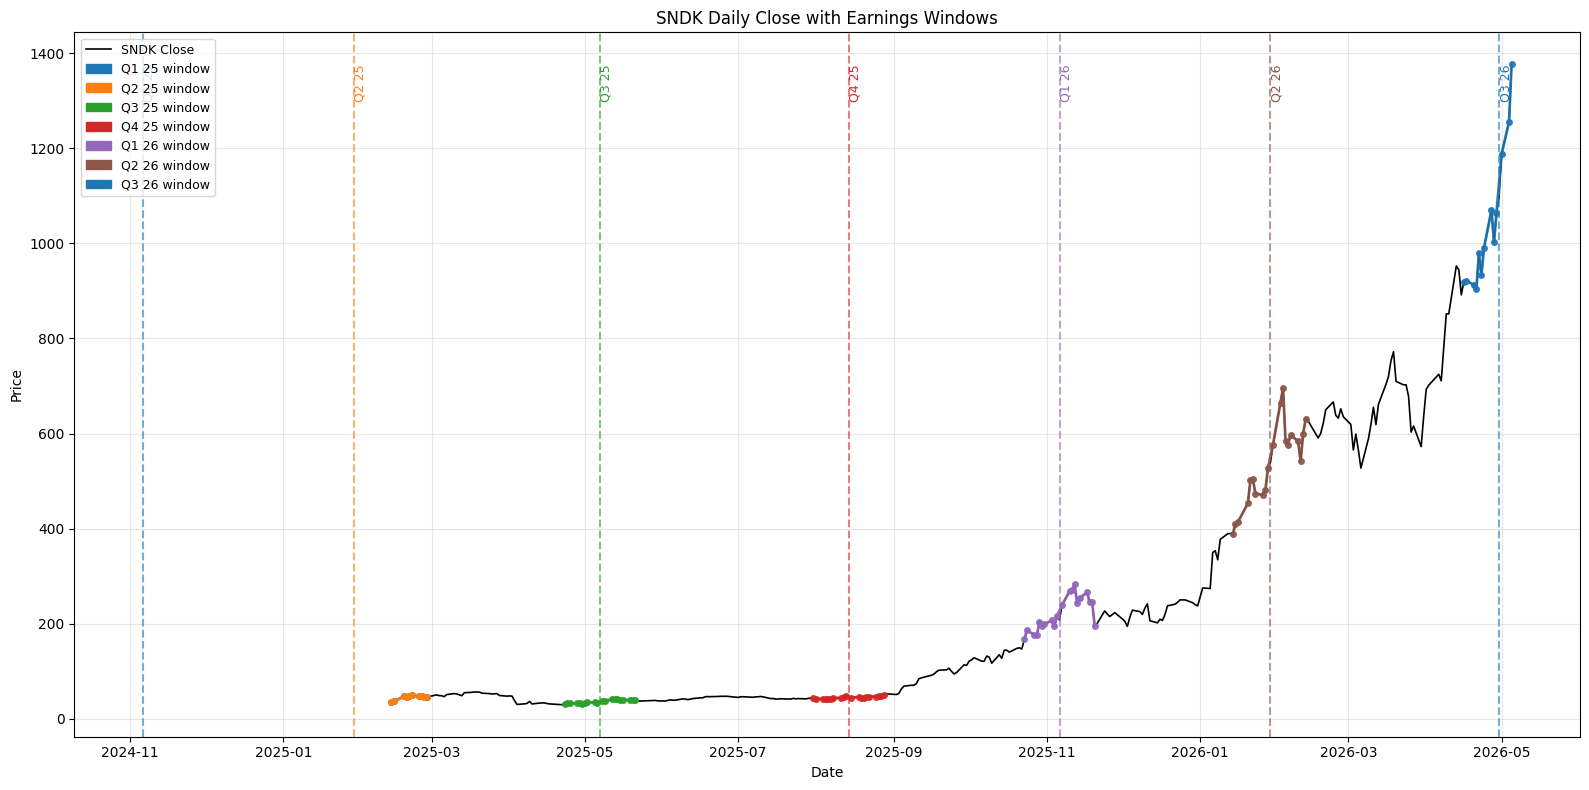

In [2]:

# 颜色列表
colors = [
    "#1f77b4",  # 蓝
    "#ff7f0e",  # 橙
    "#2ca02c",  # 绿
    "#d62728",  # 红
    "#9467bd",  # 紫
    "#8c564b",  # 棕
]

plt.figure(figsize=(16, 8))

# 画总的收盘价曲线
plt.plot(daily_df["Date"], daily_df["Close"], color="black", linewidth=1.2, label="SNDK Close")

legend_patches = []

for i, (_, row) in enumerate(df.iterrows()):
    ed = row["earnings_date"]
    color = colors[i % len(colors)]

    # 取窗口：财报日前15个交易日 + 财报后15个交易日
    before_window = daily_df[daily_df["Date"] < ed].tail(window_width)
    after_window = daily_df[daily_df["Date"] > ed].head(window_width)
    window = pd.concat([before_window, after_window], ignore_index=True)

    if window.empty:
        continue

    # 高亮该窗口内的点
    plt.plot(
        window["Date"],
        window["Close"],
        marker="o",
        linestyle="-",
        color=color,
        linewidth=2,
        markersize=4,
        alpha=0.9
    )

    # 财报日期虚线
    plt.axvline(ed, color=color, linestyle="--", alpha=0.6)

    # 标签
    plt.text(
        ed,
        daily_df["Close"].max(),
        row["quarter"],
        rotation=90,
        verticalalignment="top",
        fontsize=9,
        color=color
    )

    legend_patches.append(Patch(color=color, label=f'{row["quarter"]} window'))

plt.title("SNDK Daily Close with Earnings Windows")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)

# 图例
handles, labels = plt.gca().get_legend_handles_labels()
handles.extend(legend_patches)
plt.legend(handles=handles, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

2026-05-05 23:25:56,775 | 22592 | 29076 | [open_context_base.py:409] _init_connect_sync: New connect ready: conn=7457450520318432116(1) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x00000215D0796A50>
2026-05-05 23:25:56,968 | 22592 | 27908 | [open_context_base.py:516] on_disconnect: Disconnected: conn=0(1) reason=CallClose


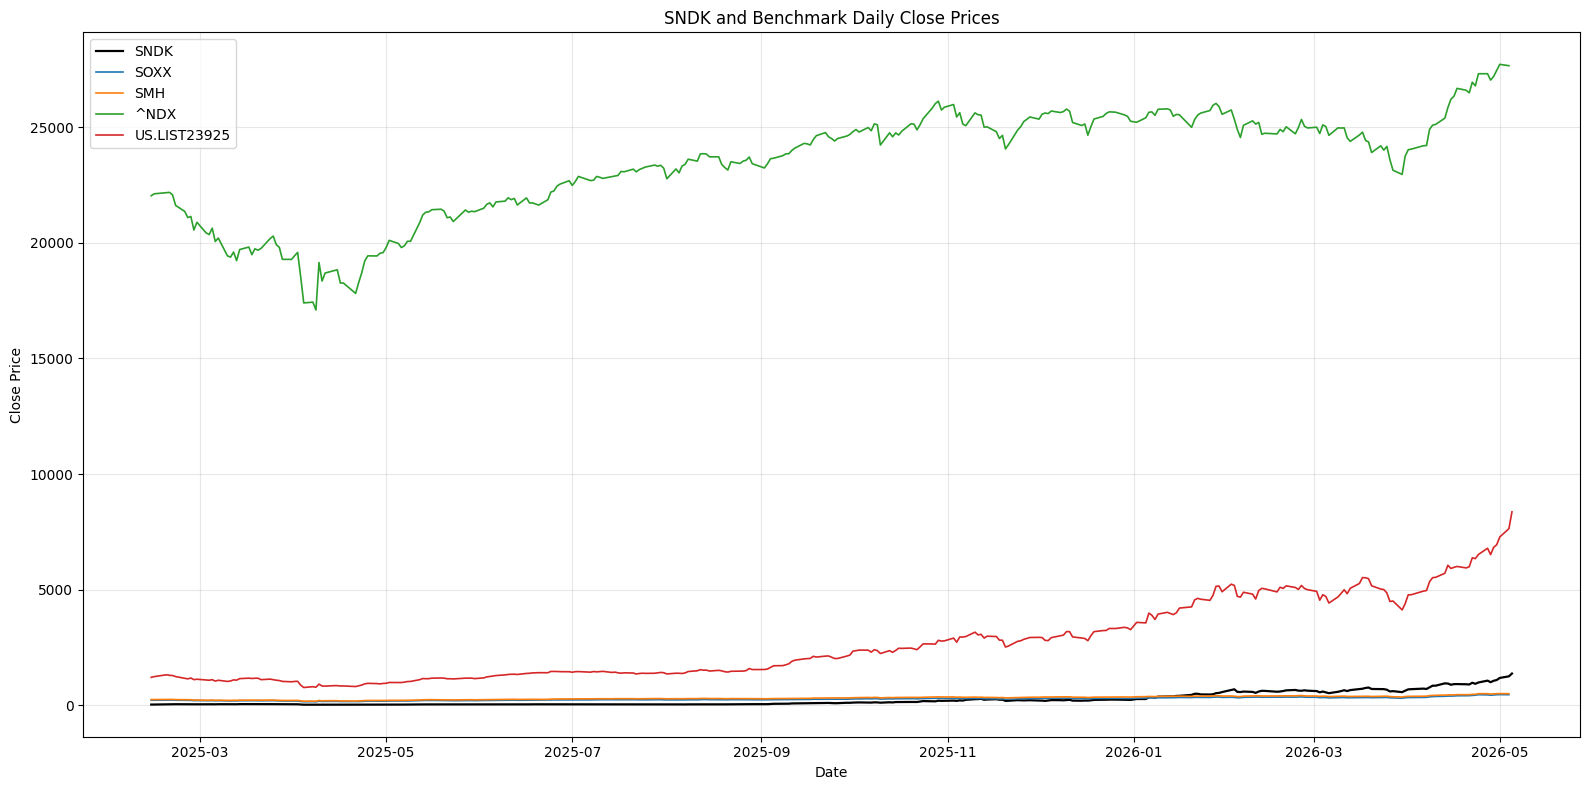

2026-05-05 23:44:13,310 | 22592 | 27908 | [open_context_base.py:516] on_disconnect: Disconnected: conn=0(4) reason=CallClose
2026-05-05 23:44:38,776 | 22592 | 27908 | [open_context_base.py:516] on_disconnect: Disconnected: conn=0(5) reason=CallClose
2026-05-06 00:53:41,723 | 22592 | 27908 | [open_context_base.py:519] on_disconnect: Disconnected: conn=7457453909942097506(2) reason=RemoteClose msg=
2026-05-06 00:53:41,841 | 22592 | 27908 | [open_context_base.py:519] on_disconnect: Disconnected: conn=7457454235226203575(3) reason=RemoteClose msg=


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# =========================================================
# 1) 你的 SNDK 日线
# =========================================================
sndk_df = daily_df.copy()
sndk_df["Date"] = pd.to_datetime(sndk_df["Date"], errors="coerce")
sndk_df = sndk_df[["Date", "Close"]].dropna().sort_values("Date").reset_index(drop=True)

if hasattr(sndk_df["Date"].dt, "tz") and sndk_df["Date"].dt.tz is not None:
    try:
        sndk_df["Date"] = sndk_df["Date"].dt.tz_localize(None)
    except Exception:
        try:
            sndk_df["Date"] = sndk_df["Date"].dt.tz_convert(None)
        except Exception:
            pass

sndk_start = sndk_df["Date"].min()
sndk_end = sndk_df["Date"].max()

# =========================================================
# 2) 从 Yahoo 拉取 3 条 benchmark 日线
# =========================================================
def fetch_yahoo_daily_close(ticker, start=None, end=None):
    px = yf.download(
        ticker,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=False,
        progress=False
    )
    if px is None or px.empty:
        raise ValueError(f"Failed to fetch Yahoo data for {ticker}")
    px = px.reset_index()
    px["Date"] = pd.to_datetime(px["Date"], errors="coerce")
    px = px[["Date", "Close"]].dropna()
    px = px.sort_values("Date").reset_index(drop=True)
    return px

soxx_df = fetch_yahoo_daily_close("SOXX", start=sndk_start, end=sndk_end)
smh_df = fetch_yahoo_daily_close("SMH", start=sndk_start, end=sndk_end)
ndx_df = fetch_yahoo_daily_close("^NDX", start=sndk_start, end=sndk_end)

# =========================================================
# 3) 从 FUTU 拉取 LIST23925 日线
# =========================================================
def fetch_futu_daily_close(code, start=None, end=None, host="127.0.0.1", port=11111):
    from futu import OpenQuoteContext, KLType

    quote_ctx = OpenQuoteContext(host=host, port=port)
    try:
        result = quote_ctx.request_history_kline(
            code=code,
            start=start,
            end=end,
            ktype=KLType.K_DAY
        )

        ret = result[0]
        data = result[1]

        if ret != 0 or data is None or data.empty:
            raise ValueError(f"Failed to fetch FUTU data for {code}: {data}")

        if "time_key" in data.columns:
            data["Date"] = pd.to_datetime(data["time_key"], errors="coerce")
        elif "Date" in data.columns:
            data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
        else:
            raise ValueError("FUTU data does not contain time_key or Date column.")

        close_col = "close" if "close" in data.columns else "Close"
        if close_col not in data.columns:
            raise ValueError("FUTU data does not contain close/Close column.")

        out = data[["Date", close_col]].copy()
        out = out.rename(columns={close_col: "Close"})
        out = out.dropna().sort_values("Date").reset_index(drop=True)
        return out

    finally:
        quote_ctx.close()

list23925_df = fetch_futu_daily_close(
    code="US.LIST23925",
    start=sndk_start.strftime("%Y-%m-%d"),
    end=sndk_end.strftime("%Y-%m-%d"),
    host="127.0.0.1",
    port=11111
)

# 再保险：裁剪到 SNDK 时间范围内
list23925_df = list23925_df[
    (list23925_df["Date"] >= sndk_start) &
    (list23925_df["Date"] <= sndk_end)
].copy()

# =========================================================
# 4) 画图
# =========================================================
plt.figure(figsize=(16, 8))

plt.plot(sndk_df["Date"], sndk_df["Close"], label="SNDK", color="black", linewidth=1.6)
plt.plot(soxx_df["Date"], soxx_df["Close"], label="SOXX", linewidth=1.2)
plt.plot(smh_df["Date"], smh_df["Close"], label="SMH", linewidth=1.2)
plt.plot(ndx_df["Date"], ndx_df["Close"], label="^NDX", linewidth=1.2)
plt.plot(list23925_df["Date"], list23925_df["Close"], label="US.LIST23925", linewidth=1.2)

plt.title("SNDK and Benchmark Daily Close Prices")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()



In [9]:
# =========================================================
# 1) 自动识别收盘价列
# =========================================================
def normalize_price_df(df):
    out = df.copy()

    # 处理 MultiIndex 列
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = ["_".join([str(x) for x in col if str(x) != ""]) for col in out.columns]

    # 统一日期列
    if "Date" not in out.columns:
        if "time_key" in out.columns:
            out["Date"] = pd.to_datetime(out["time_key"], errors="coerce")
        elif "Datetime" in out.columns:
            out["Date"] = pd.to_datetime(out["Datetime"], errors="coerce")
        else:
            out = out.reset_index()
            if "Date" not in out.columns:
                out = out.rename(columns={out.columns[0]: "Date"})
            out["Date"] = pd.to_datetime(out["Date"], errors="coerce")
    else:
        out["Date"] = pd.to_datetime(out["Date"], errors="coerce")

    # 自动找价格列
    candidate_cols = [
        c for c in out.columns
        if c != "Date" and pd.api.types.is_numeric_dtype(out[c])
    ]

    # 优先顺序
    preferred = ["Close", "close", "Adj Close", "adjclose", "adj_close"]
    price_col = None
    for p in preferred:
        if p in out.columns:
            price_col = p
            break

    if price_col is None:
        if len(candidate_cols) == 0:
            raise ValueError(f"No numeric price column found in columns: {out.columns.tolist()}")
        price_col = candidate_cols[0]

    out = out[["Date", price_col]].rename(columns={price_col: "Close"})
    out = out.dropna().sort_values("Date").reset_index(drop=True)
    return out


sndk_df = normalize_price_df(sndk_df)
soxx_df = normalize_price_df(soxx_df)
smh_df = normalize_price_df(smh_df)
ndx_df = normalize_price_df(ndx_df)
list23925_df = normalize_price_df(list23925_df)
import pandas as pd
import numpy as np

# =========================================================
# 2) 计算日收益率
# =========================================================
def make_ret_df(df, ret_name):
    out = df.copy().sort_values("Date").reset_index(drop=True)
    out[ret_name] = out["Close"].pct_change()
    return out[["Date", ret_name]]

sndk_ret = make_ret_df(sndk_df, "ret_sndk")
soxx_ret = make_ret_df(soxx_df, "ret_soxx")
smh_ret = make_ret_df(smh_df, "ret_smh")
ndx_ret = make_ret_df(ndx_df, "ret_ndx")
list23925_ret = make_ret_df(list23925_df, "ret_list23925")

# =========================================================
# 3) 生成 alpha_df
# =========================================================
alpha_df = (
    sndk_ret.set_index("Date")
    .join(soxx_ret.set_index("Date"), how="inner")
    .join(smh_ret.set_index("Date"), how="inner")
    .join(ndx_ret.set_index("Date"), how="inner")
    .join(list23925_ret.set_index("Date"), how="inner")
    .reset_index()
)

alpha_df["alpha_soxx"] = alpha_df["ret_sndk"] - alpha_df["ret_soxx"]
alpha_df["alpha_smh"] = alpha_df["ret_sndk"] - alpha_df["ret_smh"]
alpha_df["alpha_ndx"] = alpha_df["ret_sndk"] - alpha_df["ret_ndx"]
alpha_df["alpha_list23925"] = alpha_df["ret_sndk"] - alpha_df["ret_list23925"]

# =========================================================
# 4) 确保日期格式
# =========================================================
daily_df = daily_df.copy()
daily_df["Date"] = pd.to_datetime(daily_df["Date"], errors="coerce")
daily_df = daily_df.sort_values("Date").reset_index(drop=True)

df = df.copy()
df["earnings_date"] = pd.to_datetime(df["earnings_date"], errors="coerce")
df = df.sort_values("earnings_date").reset_index(drop=True)

alpha_df = alpha_df.copy()
alpha_df["Date"] = pd.to_datetime(alpha_df["Date"], errors="coerce")
alpha_df = alpha_df.sort_values("Date").reset_index(drop=True)

# =========================================================
# 5) 按财报窗口计算 alpha 均值（百分数）
#    财报日前25个交易日 + 财报后25个交易日
# =========================================================
alpha_cols = [
    "alpha_soxx",
    "alpha_smh",
    "alpha_ndx",
    "alpha_list23925",
]

records = []

for _, row in df.iterrows():
    ed = row["earnings_date"]
    if pd.isna(ed):
        continue

    if ed < daily_df["Date"].min():
        continue

    before_window = daily_df[daily_df["Date"] < ed].tail(25)
    after_window = daily_df[daily_df["Date"] > ed].head(25)

    window_dates = pd.concat(
        [before_window[["Date"]], after_window[["Date"]]],
        ignore_index=True
    )

    if window_dates.empty:
        continue

    window_alpha = alpha_df[alpha_df["Date"].isin(window_dates["Date"])].copy()

    if window_alpha.empty:
        continue

    rec = {
        "quarter": row["quarter"],
        "earnings_date": ed,
        "window_start": window_dates["Date"].min(),
        "window_end": window_dates["Date"].max(),
        "num_obs_used": len(window_alpha),
    }

    for c in alpha_cols:
        rec[f"mean_{c}_pct"] = window_alpha[c].mean() * 100

    records.append(rec)

window_alpha_mean_df = pd.DataFrame(records)

# =========================================================
# 6) 只保留 quarter + 四个均值列
# =========================================================
window_alpha_mean_df = window_alpha_mean_df[
    [
        "quarter",
        "mean_alpha_soxx_pct",
        "mean_alpha_smh_pct",
        "mean_alpha_ndx_pct",
        "mean_alpha_list23925_pct",
    ]
].copy()

# =========================================================
# 7) 在最上面插入 Q2 25 和 Q1 25
# =========================================================
new_rows = pd.DataFrame({
    "quarter": ["Q2 25", "Q1 25"],
    "mean_alpha_soxx_pct": [np.nan, np.nan],
    "mean_alpha_smh_pct": [np.nan, np.nan],
    "mean_alpha_ndx_pct": [np.nan, np.nan],
    "mean_alpha_list23925_pct": [np.nan, np.nan],
})

window_alpha_mean_df = pd.concat([new_rows, window_alpha_mean_df], ignore_index=True)

display(window_alpha_mean_df)

,quarter,mean_alpha_soxx_pct,mean_alpha_smh_pct,mean_alpha_ndx_pct,mean_alpha_list23925_pct
0,Q2 25,NaN,NaN,NaN,NaN
1,Q1 25,NaN,NaN,NaN,NaN
2,Q3 25,-0.578767,-0.624181,-0.442046,-0.786989
3,Q4 25,1.530650,1.501936,1.555322,0.950127
4,Q1 26,1.234155,1.288101,1.399936,0.932972
5,Q2 26,1.631281,1.655256,1.843784,1.059044
6,Q3 26,1.175371,1.341592,1.749339,0.642828


In [5]:
final_alpha_table = df.join(window_alpha_mean_df.iloc[:, -4:], how="left")
display(final_alpha_table)

,earnings_date,quarter,actual_revenue_b,consensus_estimate_revenue_b,actual_EPS,consensus_estimate_EPS,Profit,revenue_surprise_pct,eps_surprise_ratio,revenue_qoq_growth_pct,...,profit_qoq_growth_pct,revenue_yoy_growth_pct,eps_yoy_growth_pct,profit_yoy_growth_pct,avg_close_20tradingdays_around_earnings,num_obs_used,mean_alpha_soxx_pct,mean_alpha_smh_pct,mean_alpha_ndx_pct,mean_alpha_list23925_pct
0,2024-11-06,Q1 25,1.883,NaN,1.81,NaN,263,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
1,2025-01-29,Q2 25,1.876,1.98,1.23,1.16,178,-5.252525,6.034483,-0.371747,...,-32.319392,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
2,2025-05-07,Q3 25,1.695,1.52,-0.30,-0.40,-43,11.513158,25.000000,-9.648188,...,-124.157303,NaN,NaN,NaN,36.319500,20,-0.578767,-0.624181,-0.442046,-0.786989
3,2025-08-14,Q4 25,1.901,1.94,0.29,0.05,42,-2.010309,480.000000,12.153392,...,197.674419,NaN,NaN,NaN,44.869000,20,1.530650,1.501936,1.555322,0.950127
4,2025-11-06,Q1 26,2.308,2.26,1.22,0.84,181,2.123894,45.238095,21.409784,...,330.952381,22.570366,-32.596685,-31.178707,221.769502,20,1.234155,1.288101,1.399936,0.932972
5,2026-01-29,Q2 26,3.025,2.60,6.20,3.38,967,16.346154,83.431953,31.065858,...,434.254144,61.247335,404.065041,443.258427,533.629001,20,1.631281,1.655256,1.843784,1.059044
6,2026-04-30,Q3 26,5.950,4.16,23.41,12.48,3675,43.028846,87.580128,96.694215,...,280.041365,251.032448,7903.333333,8646.511628,1039.580764,13,1.175371,1.341592,1.749339,0.642828


现有特征列：
['actual_revenue_b', 'actual_EPS', 'Profit', 'mean_alpha_ndx_pct']

缺失特征列：
[]

用于回归的数据：


,quarter,avg_close_20tradingdays_around_earnings,actual_revenue_b,actual_EPS,Profit,mean_alpha_ndx_pct
0,Q3 25,36.319500,1.695,-0.30,-43,-0.442046
1,Q4 25,44.869000,1.901,0.29,42,1.555322
2,Q1 26,221.769502,2.308,1.22,181,1.399936
3,Q2 26,533.629001,3.025,6.20,967,1.843784
4,Q3 26,1039.580764,5.950,23.41,3675,1.749339



R^2   = 1.0000
RMSE  = 0.0000
MAE   = 0.0000
MAPE% = 0.00%

回归系数：


,feature,coef
1,actual_EPS,80403.791763
0,actual_revenue_b,-14689.868597
3,mean_alpha_ndx_pct,-1166.989948
2,Profit,-494.972546


Intercept = 27257.1018


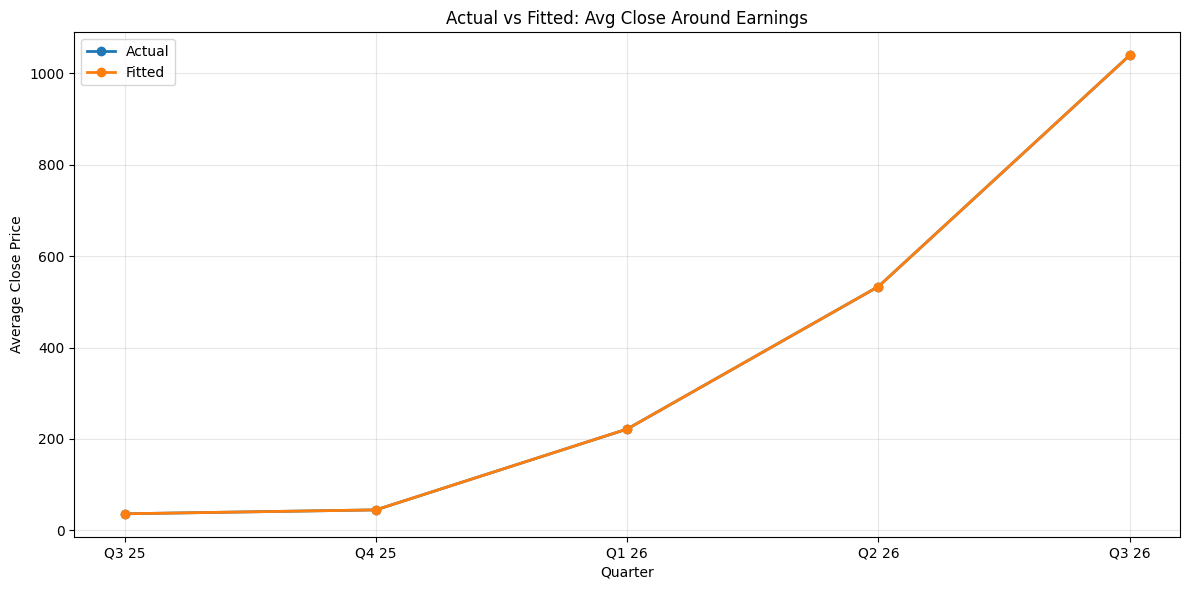

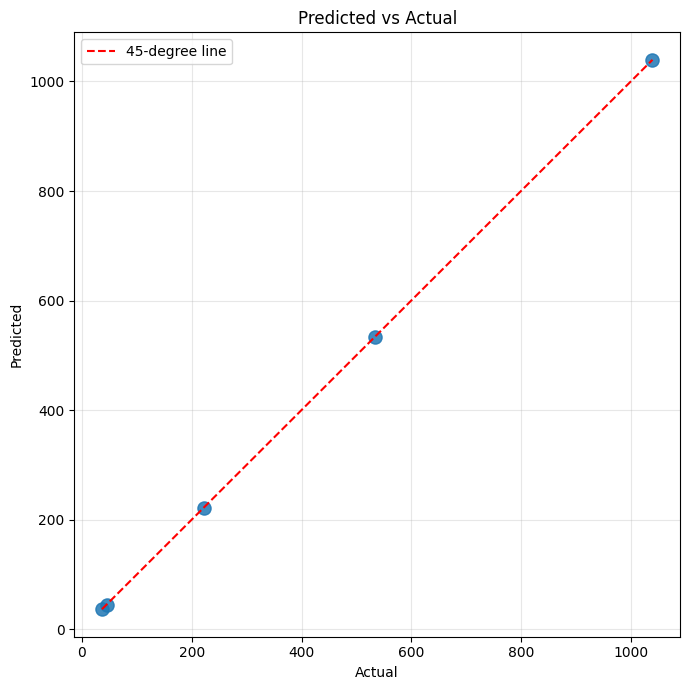

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# 1) 目标变量和候选特征
# =========================================================
target_col = f"avg_close_{window_width*2}tradingdays_around_earnings"

candidate_feature_cols = [
    "actual_revenue_b",
    "actual_EPS",
    "Profit",
#     "revenue_surprise_pct",
#     "eps_surprise_ratio",
#     "revenue_qoq_growth_pct",
#     "eps_qoq_growth_pct",
#     "profit_qoq_growth_pct",
#     "revenue_yoy_growth_pct",
#     "eps_yoy_growth_pct",
#     "profit_yoy_growth_pct",
#     "mean_alpha_soxx_pct",
#     "mean_alpha_smh_pct",
"mean_alpha_ndx_pct",
#     "mean_alpha_list23925_pct",
]

# =========================================================
# 2) 使用 final_alpha_table
# =========================================================
model_source = final_alpha_table.copy()

# =========================================================
# 3) 检查列是否存在
# =========================================================
existing_feature_cols = [c for c in candidate_feature_cols if c in model_source.columns]
missing_feature_cols = [c for c in candidate_feature_cols if c not in model_source.columns]

print("现有特征列：")
print(existing_feature_cols)

print("\n缺失特征列：")
print(missing_feature_cols)

if target_col not in model_source.columns:
    raise KeyError(f"Target column '{target_col}' not found in final_alpha_table.")

# =========================================================
# 4) 构造建模数据
#    Y 不能缺失，X 缺失统一补 0
# =========================================================
model_df = model_source[["quarter", target_col] + existing_feature_cols].copy()

# 只保留有 Y 的行
model_df = model_df.dropna(subset=[target_col]).reset_index(drop=True)

# X 缺失补 0
for col in existing_feature_cols:
    model_df[col] = model_df[col].fillna(0)

print("\n用于回归的数据：")
display(model_df)

if len(model_df) < 2:
    raise ValueError("可用于回归的样本太少，至少需要 2 行。")

# =========================================================
# 5) 拟合线性回归
# =========================================================
X = model_df[existing_feature_cols]
y = model_df[target_col]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# =========================================================
# 6) 拟合精度
# =========================================================
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

# MAPE：避免除 0
mape = np.mean(np.abs((y - y_pred) / y.replace(0, np.nan))) * 100

print(f"\nR^2   = {r2:.4f}")
print(f"RMSE  = {rmse:.4f}")
print(f"MAE   = {mae:.4f}")
print(f"MAPE% = {mape:.2f}%")

# =========================================================
# 7) 回归系数
# =========================================================
coef_df = pd.DataFrame({
    "feature": existing_feature_cols,
    "coef": model.coef_
}).sort_values("coef", key=np.abs, ascending=False)

print("\n回归系数：")
display(coef_df)

print(f"Intercept = {model.intercept_:.4f}")

# =========================================================
# 8) 图1：实际值 vs 拟合值
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(model_df["quarter"], y.values, marker="o", linewidth=2, label="Actual")
plt.plot(model_df["quarter"], y_pred, marker="o", linewidth=2, label="Fitted")
plt.title("Actual vs Fitted: Avg Close Around Earnings")
plt.xlabel("Quarter")
plt.ylabel("Average Close Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 9) 图2：预测值 vs 实际值散点图
# =========================================================
plt.figure(figsize=(7, 7))
plt.scatter(y, y_pred, s=90, alpha=0.85)

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="45-degree line")

plt.title("Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

实际使用的特征： ['actual_revenue_b', 'actual_EPS', 'Profit']

用于回归的数据：


,quarter,avg_close_50tradingdays_around_earnings,actual_revenue_b,actual_EPS,Profit
0,Q3 25,36.613900,1.695,-0.30,-43
1,Q4 25,53.781100,1.901,0.29,42
2,Q1 26,194.135001,2.308,1.22,181
3,Q2 26,486.275602,3.025,6.20,967



R^2   = 1.0000
RMSE  = 0.0000
MAE   = 0.0000
MAPE% = 0.00%

回归系数：


,feature,coef
1,actual_EPS,-1909.926777
0,actual_revenue_b,652.651821
2,Profit,11.877385


Intercept = -1131.8814


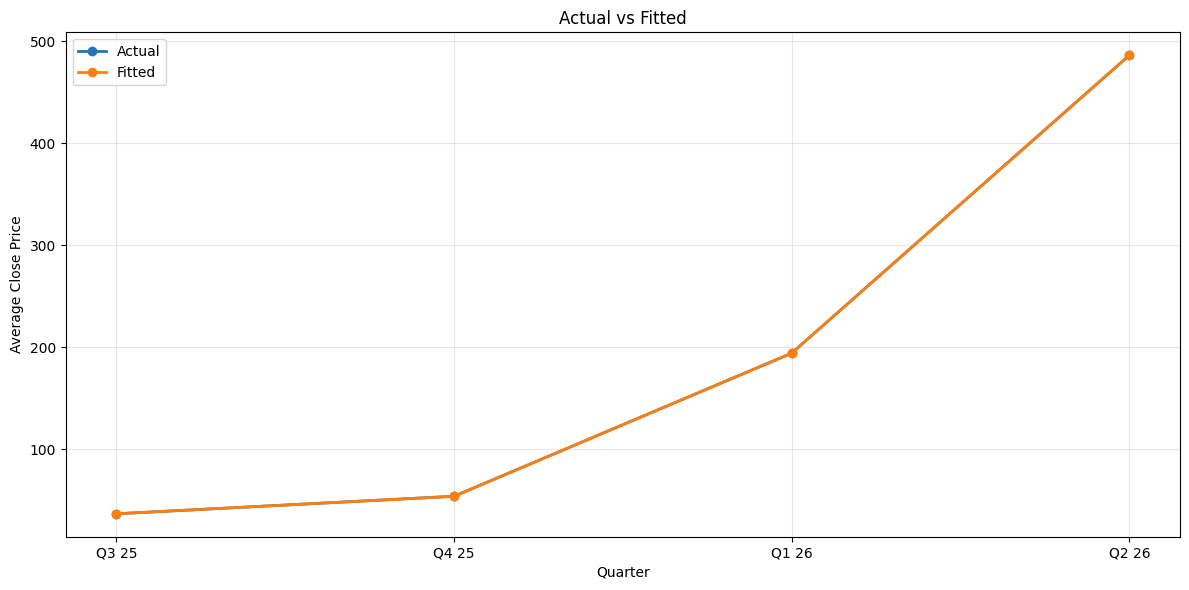

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

target_col = f"avg_close_{window_width*2}tradingdays_around_earnings"

selected_features = [
    "actual_revenue_b",
    "actual_EPS",
    "Profit",
    #"mean_alpha_ndx_pct",
]


model_source = final_alpha_table.copy()

# 只保留存在的列
existing_feature_cols = [c for c in selected_features if c in model_source.columns]
print("实际使用的特征：", existing_feature_cols)

if target_col not in model_source.columns:
    raise KeyError(f"Target column '{target_col}' not found in final_alpha_table.")

# 构造数据
model_df = model_source[["quarter", target_col] + existing_feature_cols].copy()

# 只保留有 Y 的行
model_df = model_df.dropna(subset=[target_col]).reset_index(drop=True)

# X 缺失补 0
for col in existing_feature_cols:
    model_df[col] = model_df[col].fillna(0)

print("\n用于回归的数据：")
display(model_df)

if len(model_df) < 2:
    raise ValueError("可用于回归的样本太少，至少需要 2 行。")

# 拟合
X = model_df[existing_feature_cols]
y = model_df[target_col]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# 精度
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
mape = np.mean(np.abs((y - y_pred) / y.replace(0, np.nan))) * 100

print(f"\nR^2   = {r2:.4f}")
print(f"RMSE  = {rmse:.4f}")
print(f"MAE   = {mae:.4f}")
print(f"MAPE% = {mape:.2f}%")

# 系数
coef_df = pd.DataFrame({
    "feature": existing_feature_cols,
    "coef": model.coef_
}).sort_values("coef", key=np.abs, ascending=False)

print("\n回归系数：")
display(coef_df)

print(f"Intercept = {model.intercept_:.4f}")

# 图
plt.figure(figsize=(12, 6))
plt.plot(model_df["quarter"], y.values, marker="o", linewidth=2, label="Actual")
plt.plot(model_df["quarter"], y_pred, marker="o", linewidth=2, label="Fitted")
plt.title("Actual vs Fitted")
plt.xlabel("Quarter")
plt.ylabel("Average Close Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
from futu import *

quote_ctx = OpenQuoteContext(host='127.0.0.1', port=11111)

print([x for x in dir(quote_ctx) if "financial" in x.lower() or "report" in x.lower() or "earning" in x.lower()])

quote_ctx.close()

2026-05-05 23:44:13,308 | 22592 | 29076 | [open_context_base.py:409] _init_connect_sync: New connect ready: conn=7457455119511530087(4) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x00000215F9B58890>
[]


In [14]:
from futu import *

quote_ctx = OpenQuoteContext(host='127.0.0.1', port=11111)
print("quote_ctx methods:")
print([x for x in dir(quote_ctx) if not x.startswith("_")])

quote_ctx.close()

2026-05-05 23:44:38,774 | 22592 | 29076 | [open_context_base.py:409] _init_connect_sync: New connect ready: conn=7457455226250427138(5) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x00000215F9513710>
quote_ctx methods:
['can_send_proto', 'close', 'conn_str', 'get_async_conn_id', 'get_broker_queue', 'get_capital_distribution', 'get_capital_flow', 'get_code_change', 'get_cur_kline', 'get_delay_statistics', 'get_future_info', 'get_global_state', 'get_history_kl_quota', 'get_holding_change_list', 'get_ipo_list', 'get_login_user_id', 'get_market_snapshot', 'get_market_state', 'get_option_chain', 'get_option_expiration_date', 'get_order_book', 'get_owner_plate', 'get_plate_list', 'get_plate_stock', 'get_price_reminder', 'get_referencestock_list', 'get_rehab', 'get_rt_data', 'get_rt_ticker', 'get_stock_basicinfo', 'get_stock_filter', 'get_stock_quote', 'get_sync_conn_id', 'get_user_info', 'get_user_security', 'get_user_security_group', 'get_warrant', 'handle_packet', 'ha

In [ ]:
from futu import *

trade_ctx = OpenSecTradeContext(filter_trdmarket=TrdMarket.US, host='127.0.0.1', port=11111)
print("trade_ctx methods:")
print([x for x in dir(trade_ctx) if not x.startswith("_")])

trade_ctx.close()

In [15]:
import futu

print([x for x in dir(futu) if "Context" in x])

['ContextStatus', 'OpenCNTradeContext', 'OpenFutureTradeContext', 'OpenHKCCTradeContext', 'OpenHKTradeContext', 'OpenQuoteContext', 'OpenSecTradeContext', 'OpenUSTradeContext']
